In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
# from skimage.util import montage
from skimage import io

from skimage.util import view_as_windows


In [2]:
def montage(A, m, n):
    '''
    Create a montage matrix with mn images
    Inputs:
    A: original MxN image matrix with M images (N pixels/image), M > mn
    m, n: m rows & n columns, total mn images
    Output:
    M: montage matrix containing mn images
    '''
    
    sz = np.sqrt(A.shape[1]).astype('int') # image size sz x sz
    M = np.zeros((m*sz, n*sz)) # montage image
    
    for i in range(m) :
        for j in range(n) :
            M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
                A[i*n+j,:].reshape(sz, sz)

    return M

In [19]:

# imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
# X = io.imread(imgfile, as_gray = True)

def patching_SVD(imgfile, patch_sz = 16):
    X = io.imread(imgfile, as_gray = True)
    # 將圖像切割小區域
    N, p = X.shape # 
    patches = view_as_windows(X, (patch_sz, patch_sz), \
                                     step=patch_sz)
    M = patches.reshape(-1, patch_sz * patch_sz) # flatten the patches
    U, E, VT = svd(M, full_matrices = False)
    q = (min(M.shape[0], M.shape[1]) / np.array([1, 8, 16, 24])).astype('int') # how many components (dimensions) to keep

    fig, ax = plt.subplots(1, len(q), figsize=(8, 3))
    for i, r in enumerate(q):
        Mq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :] 
        ax[i].imshow(montage(Mq, int(N/patch_sz), int(p/patch_sz)), cmap = 'gray')
        ratio = M.shape[1] * M.shape[0] / (U.shape[0] + VT.shape[1] + 1) / r
        if i >= 1:
            ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
        else:
            ax[i].set_title('Original image') 
        ax[i].set_xticks([])
        ax[i].set_yticks([])

    plt.tight_layout()
    # plt.suptitle("patch size = {} x {}".format(patch_sz, patch_sz))
    plt.show()

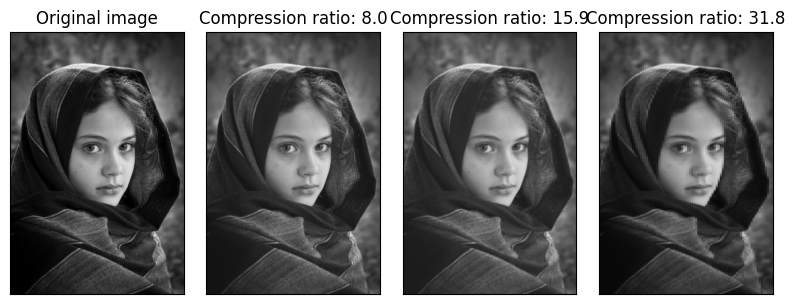

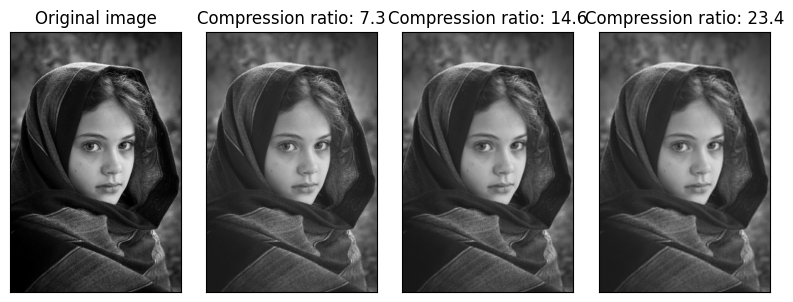

In [20]:
imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
# imgfile = "pictures/Lenna.png" # 512x512x3
patching_SVD(imgfile, patch_sz = 8)
patching_SVD(imgfile, patch_sz = 16)